In [4]:
import pandas as pd
help_analysed = pd.read_csv("Hansard_Complete_100k.csv")
help_analysed.head(3)

,Hit,LeftContext,TargetWord,RightContext,DepVar,HelpClass,HelpInflection,VerbLemma,InterveningWords,ObjPresent,...,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,SubjType.1,SubjType.2,CompLemma,CompTag
0,19239.0,are with President Kruger. They are against En...,help,to pay the bill for this war. Those who talk o...,TO,VERB,VB,pay,0.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,PRON,PRON,mean,VBZ
1,19240.0,"on the spot there, I believe them to be on a g...",helped,to increase the suffering of the wounded. MR. ...,TO,VERB,VBN,increase,0.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,PRON,PRON,reduce,VBN
2,16662.0,"the National Telephone Company, and have learn...",help,thinking that the noble Duke will not object i...,ING,VERB,VB,think,0.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,PRON,PRON,make,VB


In [8]:
import pandas as pd

# Load the data
help_analysed = pd.read_csv("Hansard_Complete_100k.csv")

# Calculate total word count
total_word_count = help_analysed['WordCount'].sum()

print(f"Total Word Count: {total_word_count:,}")

# Additional statistics
print(f"\nWord Count Statistics:")
print(f"Average words per record: {help_analysed['WordCount'].mean():.2f}")
print(f"Median words per record: {help_analysed['WordCount'].median():.2f}")
print(f"Min words: {help_analysed['WordCount'].min()}")
print(f"Max words: {help_analysed['WordCount'].max()}")
print(f"Standard deviation: {help_analysed['WordCount'].std():.2f}")

Total Word Count: 535,995,033.0

Word Count Statistics:
Average words per record: 24411.12
Median words per record: 23163.00
Min words: 18.0
Max words: 96197.0
Standard deviation: 17970.77


In [21]:
import pandas as pd

# Load the data
help_analysed = pd.read_csv("Hansard_Complete_100k.csv")

def parse_mixed_dates(date_str):
    if pd.isna(date_str) or date_str == 'N/A':
        return pd.NaT
    
    date_str = str(date_str).strip()
    
    # Try YYYY-MM-DD format first (pre-1900)
    try:
        parsed = pd.to_datetime(date_str, format='%Y-%m-%d')
        return parsed
    except:
        pass
    
    # Try MM/DD/YYYY format (post-1900)
    try:
        parsed = pd.to_datetime(date_str, format='%m/%d/%Y')
        return parsed
    except:
        pass
    
    return pd.NaT

# Apply the function to convert dates
help_analysed['SittingDate'] = help_analysed['SittingDate'].apply(parse_mixed_dates)

# Check for invalid dates
# invalid_dates = help_analysed[help_analysed['SittingDate'].isna()]
# print(f"Invalid dates found: {len(invalid_dates)}")
# if len(invalid_dates) > 0:
#     print("Rows with invalid dates:")
#     print(invalid_dates[['Hit', 'SittingDate']])

# Get min and max dates
min_date = help_analysed['SittingDate'].min()
max_date = help_analysed['SittingDate'].max()

print(f"\nDate range:")
print(f"Minimum Date: {min_date}")
print(f"Maximum Date: {max_date}")

# Save cleaned data
help_analysed.to_csv("Hansard_Complete_100k_cleaned.csv", index=False)
print("\nCleaned data saved!")


Date range:
Minimum Date: 1880-02-13 00:00:00
Maximum Date: 1979-12-18 00:00:00

Cleaned data saved!


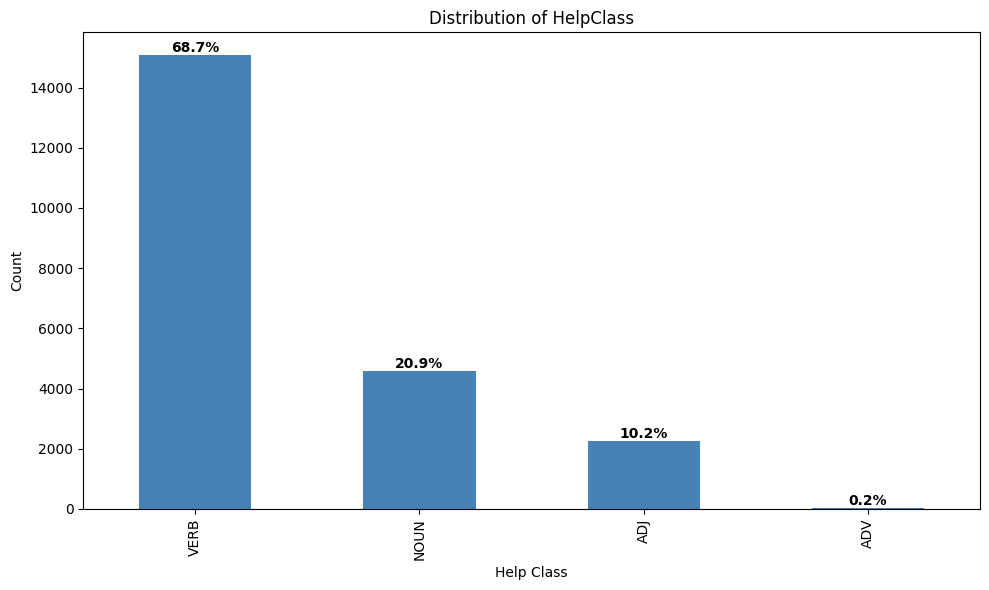

HelpClass Value Counts:
---------------------------------------------------------------------------
VERB         | 15,079 ( 60.8%)
NOUN         |  4,585 ( 18.5%)
ADJ          |  2,250 (  9.1%)
ADV          |     43 (  0.2%)
Total       | 24,785 (100.0%)


In [24]:
import matplotlib.pyplot as plt

# Get value counts
help_class_counts = help_analysed['HelpClass'].value_counts()

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))
help_class_counts.plot(kind='bar', color='steelblue', ax=ax)

# Add percentage labels on top of bars
total = help_class_counts.sum()
for i, (category, count) in enumerate(help_class_counts.items()):
    percentage = (count / total) * 100
    ax.text(i, count, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Distribution of HelpClass')
ax.set_xlabel('Help Class')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

# Display value counts below
print("HelpClass Value Counts:")
print("---" * 25)
for category, count in help_class_counts.items():
    percentage = (count / len(help_analysed)) * 100
    print(f"{category:12} | {count:6,} ({percentage:5.1f}%)")

print(f"Total       | {len(help_analysed):6,} (100.0%)")

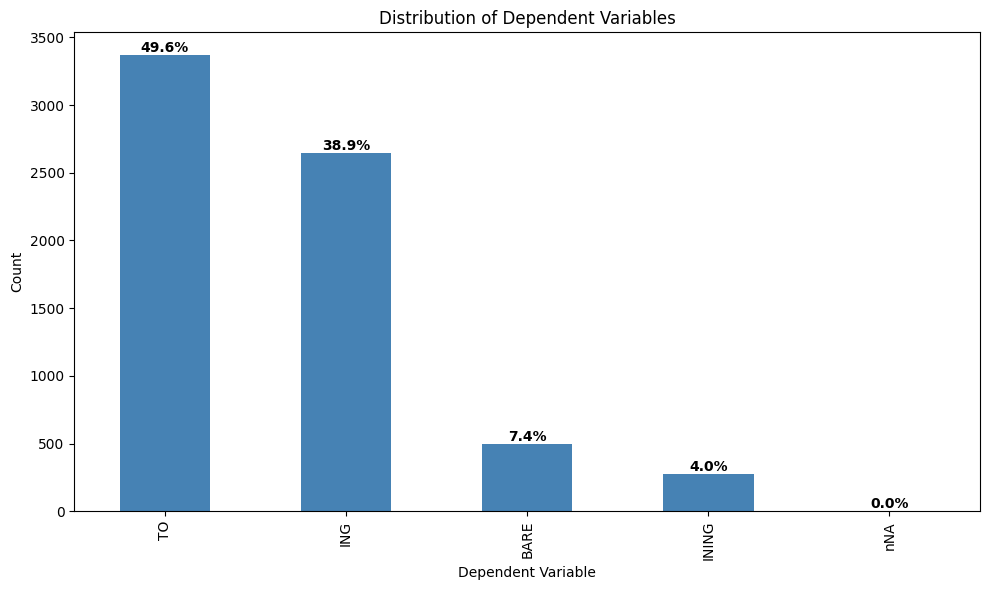

Dependent Variable Value Counts:
---------------------------------------------------------------------------
TO           |  3,369 ( 13.6%)
ING          |  2,643 ( 10.7%)
BARE         |    500 (  2.0%)
INING        |    274 (  1.1%)
nNA          |      1 (  0.0%)
Total       | 24,785 (100.0%)


In [ ]:
import matplotlib.pyplot as plt

# Doing the same for dependent variable 
dep_var_counts = help_analysed['DepVar'].value_counts()

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))
dep_var_counts.plot(kind='bar', color='steelblue', ax=ax)

# Add percentage labels on top of bars
total = dep_var_counts.sum()
for i, (category, count) in enumerate(dep_var_counts.items()):
    percentage = (count / total) * 100
    ax.text(i, count, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Distribution of Dependent Variables')
ax.set_xlabel('Dependent Variable')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

# Display value counts below
print("Dependent Variable Value Counts:")
print("---" * 25)
for category, count in dep_var_counts.items():
    percentage = (count / len(help_analysed)) * 100
    print(f"{category:12} | {count:6,} ({percentage:5.1f}%)")

print(f"Total       | {len(help_analysed):6,} (100.0%)")

Date range: 1880-02-13 to 1979-12-18

Cross-tabulation (PreceedingTo vs Time Period):
TimePeriod   Period 1\n(1880-1913)  Period 2\n(1913-1946)  \
PrecedingTo                                                 
NOtoBefore                    1701                   3053   
YEStoBefore                    433                   1714   

TimePeriod   Period 3\n(1946-1979)  
PrecedingTo                         
NOtoBefore                    5103  
YEStoBefore                   3086  


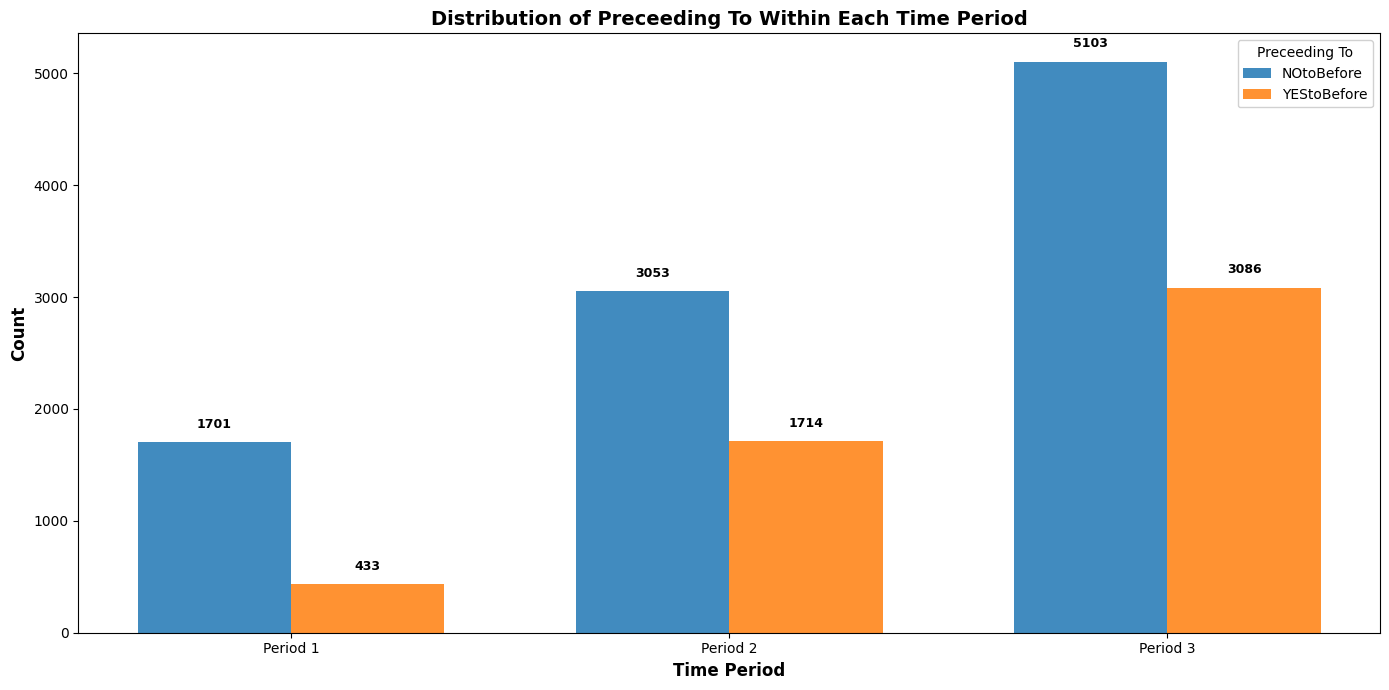

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data with parsed dates
help_analysed = pd.read_csv("Hansard_Complete_100k_cleaned.csv", parse_dates=['SittingDate'])


help_analysed = help_analysed.dropna(subset=['SittingDate'])
help_analysed = help_analysed[help_analysed['PrecedingTo'] != 'NA']

# Get date range
min_date = help_analysed['SittingDate'].min()
max_date = help_analysed['SittingDate'].max()
print(f"Date range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")

year_range = max_date.year - min_date.year
period_length = year_range / 3

period1_end = min_date.year + period_length
period2_end = min_date.year + 2 * period_length

def assign_period(date):
    year = date.year
    if year < period1_end:
        return f"Period 1\n({min_date.year:.0f}-{period1_end:.0f})"
    elif year < period2_end:
        return f"Period 2\n({period1_end:.0f}-{period2_end:.0f})"
    else:
        return f"Period 3\n({period2_end:.0f}-{max_date.year:.0f})"

# Add a new column to categorise the different date
help_analysed['TimePeriod'] = help_analysed['SittingDate'].apply(assign_period)

# ============================================
# Create grouped bar chart: Time Period by PreceedingTo
# ============================================

# Get PreceedingTo counts by Time Period
crosstab = pd.crosstab(help_analysed['PrecedingTo'], help_analysed['TimePeriod'])
print(f"\nCross-tabulation (PreceedingTo vs Time Period):")
print(crosstab)

# Create the grouped bar chart (side by side)
fig, ax = plt.subplots(figsize=(14, 7))

# Set up positions for grouped bars
periods = crosstab.columns.tolist()
preceeding_to_vars = crosstab.index.tolist()
n_periods = len(periods)
n_preceeding_to_vars = len(preceeding_to_vars)

x = np.arange(n_periods)  # the label locations (now for time periods)
width = 0.35  # the width of the bars (wider since we have fewer groups)

colors = ['#1f77b4', '#ff7f0e']  

# Plot bars for each PreceedingTo category within each time period
for i, preceeding_to in enumerate(preceeding_to_vars):
    values = crosstab.loc[preceeding_to].values
    offset = (i - 0.5) * width  # center the groups within each period
    bars = ax.bar(x + offset, values, width, label=preceeding_to, color=colors[i], alpha=0.85)
    
    # Add value labels on top of bars
    for bar, val in zip(bars, values):
        if val > 0:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + max(crosstab.max())*0.02,
                   f'{int(val)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Time Period', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Preceeding To Within Each Time Period', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([period.split('\n')[0] for period in periods])  # Show only "Period X"
ax.legend(title='Preceeding To', loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()

# Calculate column percentages (within each time period)
crosstab_col_pct = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
print("\nPercentages within each Time Period (column percentages):")
print("=" * 60)
for period in crosstab.columns:
    total = crosstab[period].sum()
    print(f"\n{period} (Total: {total}):")
    for preceeding_to in crosstab.index:
        count = crosstab.loc[preceeding_to, period]
        pct = crosstab_col_pct.loc[preceeding_to, period]
        print(f"  {preceeding_to:8}: {count:4} ({pct:5.1f}%)")

In [ ]:
# Calculate percentages for YES responses within each time period
print("\nPercentage of YES responses within each time period:")
print("="*50)

for period in periods:
    yes_count = crosstab.loc['YEStoBefore', period]
    no_count = crosstab.loc['NOtoBefore', period]
    total_count = yes_count + no_count
    percentage = (yes_count / total_count) * 100 if total_count > 0 else 0
    
    period_name = period.split('\n')[0] 
    print(f"{period_name}")
    print('PreceedingYesTo:', f'{percentage:.1f}%')


Percentage of YES responses within each time period:
Period 1
PreceedingYesTo: 20.3%
Period 2
PreceedingYesTo: 36.0%
Period 3
PreceedingYesTo: 37.7%


Date range: 1880-02-13 to 1979-12-18

Cross-tabulation (DepVar vs Time Period):
TimePeriod  Period 1\n(1880-1913)  Period 2\n(1913-1946)  \
DepVar                                                     
BARE                           19                     70   
ING                          1095                    840   
INING                          41                     89   
TO                            276                   1048   
nNA                             0                      0   

TimePeriod  Period 3\n(1946-1979)  
DepVar                             
BARE                          411  
ING                           708  
INING                         144  
TO                           2045  
nNA                             1  

Percentages within each DepVar:
TimePeriod  Period 1\n(1880-1913)  Period 2\n(1913-1946)  \
DepVar                                                     
BARE                          3.8                   14.0   
ING                          41.4 

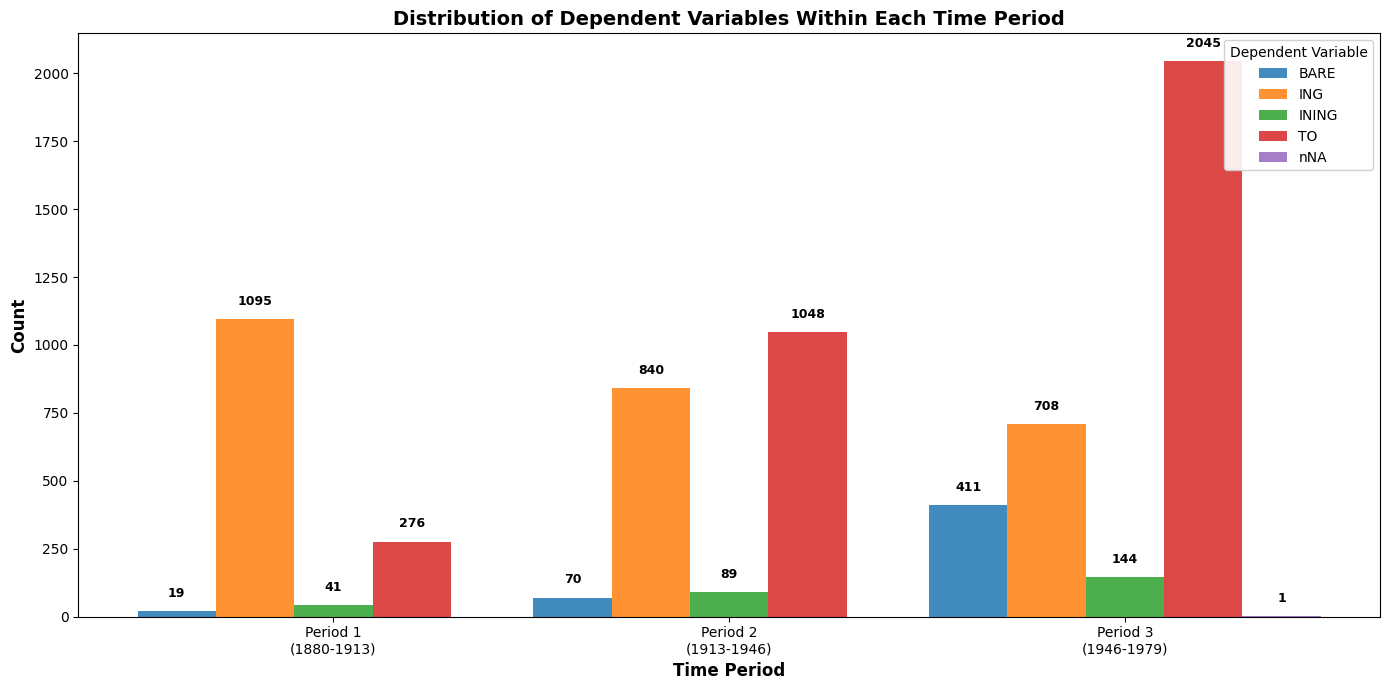


Percentages within each Time Period (column percentages):

Period 1
(1880-1913) (Total: 1431):
  BARE    :   19 (  1.3%)
  ING     : 1095 ( 76.5%)
  INING   :   41 (  2.9%)
  TO      :  276 ( 19.3%)
  nNA     :    0 (  0.0%)

Period 2
(1913-1946) (Total: 2047):
  BARE    :   70 (  3.4%)
  ING     :  840 ( 41.0%)
  INING   :   89 (  4.3%)
  TO      : 1048 ( 51.2%)
  nNA     :    0 (  0.0%)

Period 3
(1946-1979) (Total: 3309):
  BARE    :  411 ( 12.4%)
  ING     :  708 ( 21.4%)
  INING   :  144 (  4.4%)
  TO      : 2045 ( 61.8%)
  nNA     :    1 (  0.0%)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data with parsed dates
help_analysed = pd.read_csv("Hansard_Complete_100k_cleaned.csv", parse_dates=['SittingDate'])

help_analysed = help_analysed.dropna(subset=['SittingDate'])
help_analysed = help_analysed[help_analysed['DepVar'] != 'NA']

# Get date range
min_date = help_analysed['SittingDate'].min()
max_date = help_analysed['SittingDate'].max()
print(f"Date range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")

year_range = max_date.year - min_date.year
period_length = year_range / 3

period1_end = min_date.year + period_length
period2_end = min_date.year + 2 * period_length


def assign_period(date):
    year = date.year
    if year < period1_end:
        return f"Period 1\n({min_date.year:.0f}-{period1_end:.0f})"
    elif year < period2_end:
        return f"Period 2\n({period1_end:.0f}-{period2_end:.0f})"
    else:
        return f"Period 3\n({period2_end:.0f}-{max_date.year:.0f})"

# Add a new row to categorise the different date
help_analysed['TimePeriod'] = help_analysed['SittingDate'].apply(assign_period)

# ============================================
# Create grouped bar chart: DepVar by Time Period
# ============================================

# Get DepVar counts by Time Period with CrossTab
crosstab = pd.crosstab(help_analysed['DepVar'], help_analysed['TimePeriod'])
print(f"\nCross-tabulation (DepVar vs Time Period):")
print(crosstab)

crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
print(f"\nPercentages within each DepVar:")
print(crosstab_pct.round(1))

# Table setup and information
fig, ax = plt.subplots(figsize=(14, 7))
periods = crosstab.columns.tolist()
dep_vars = crosstab.index.tolist()
n_periods = len(periods)
n_depvars = len(dep_vars)
width = 0.2
gap = 0.01
x = np.arange(n_periods) * (1 + gap)  # multiply by (1 + gap) to add spacing
 
# Color for each of the Bar 
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
 
# Plot bars for each DepVar within each time period
for i, dep_var in enumerate(dep_vars):
    values = crosstab.loc[dep_var].values  
    offset = (i - 2) * width  
    bars = ax.bar(x + offset, values, width, label=dep_var, color=colors[i], alpha=0.85)

    # Add value labels on top of bars
    for bar, val in zip(bars, values):
        if val > 0:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + max(crosstab.max())*0.02,
                   f'{int(val)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Time Period', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Dependent Variables Within Each Time Period', fontsize=14, fontweight='bold')
ax.set_xticks(x)

ax.set_xticklabels([period.replace('\n', '\n') for period in periods])

ax.legend(title='Dependent Variable', loc='upper right', framealpha=0.9)


plt.tight_layout()
plt.show()


crosstab_col_pct = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
print("\nPercentages within each Time Period (column percentages):")
print("=" * 60)
for period in crosstab.columns:
    total = crosstab[period].sum()
    print(f"\n{period} (Total: {total}):")
    for dep_var in crosstab.index:
        count = crosstab.loc[dep_var, period]
        pct = crosstab_col_pct.loc[dep_var, period]
        print(f"  {dep_var:8}: {count:4} ({pct:5.1f}%)")

In [25]:
import os
import re
import pandas as pd
from datetime import datetime

# Directory containing the corpus files
corpus_dir = "/Users/muhammadmushoffa/Desktop/corpus_linguistic/Hansard100kSample"

# Lists to store data
dates = []
word_counts = []
file_data = []

# Process each file in the directory
for filename in os.listdir(corpus_dir):
    if filename.endswith('.txt'):
        filepath = os.path.join(corpus_dir, filename)
        
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                content = f.read()
                
                # Extract SittingDate from metadata
                date_match = re.search(r'<SittingDate>(.*?)</SittingDate>', content)
                if date_match:
                    date_str = date_match.group(1)
                    dates.append(date_str)
                    
                    # Parse the date
                    parsed_date = pd.to_datetime(date_str, format='%Y-%m-%d', errors='coerce')
                    
                    # Extract WordCount from metadata
                    word_count_match = re.search(r'<WordCount>(.*?)</WordCount>', content)
                    if word_count_match:
                        word_count = int(word_count_match.group(1))
                        word_counts.append(word_count)
                        
                        file_data.append({
                            'Filename': filename,
                            'SittingDate': parsed_date,
                            'WordCount': word_count
                        })
        except Exception as e:
            print(f"Error processing {filename}: {e}")

# Create DataFrame
df = pd.DataFrame(file_data)

# Calculate statistic

print(f"\nTotal files processed: {len(df)}")
print(f"Total word count: {df['WordCount'].sum():,}")

print(f"\nDate Range:")
print(f"  Earliest date: {df['SittingDate'].min()}")
print(f"  Latest date: {df['SittingDate'].max()}")

# Save results
df.to_csv("Hansard100kSample_analysis.csv", index=False)
print("\nAnalysis saved to 'Hansard100kSample_analysis.csv'")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/muhammadmushoffa/Desktop/corpus_linguistic/Hansard100kSample'